# Sample Portfolio — Static Human-Designed Allocation

The Sample Portfolio is the human judgment baseline. No algorithm chooses the weights.

Allocate based on a moderate-risk.
Weights are fixed for the entire simulation and rebalanced back to target when drift exceeds 5%.

Hypothesis is:
*Does algorithmic sophistication actually beat a simple, well-diversified static allocation?*

**Theoretical grounding**: Brinson, Hood & Beebower (1986) established that asset allocation policy explains the dominant share of portfolio return variability, not security selection or market timing.

The weights here reflect a conventional moderate-risk allocation consistent with that principle, and represent the type of predefined portfolio a moderate-risk investor would receive from a robo-advisor following a risk assessment questionnaire (something based on Losada Noya, 2024).

**Target allocation**:
- BND 20%
- TIP 10%
- TLT 10%
- GLD 10%
- VEU 25%
- VGT 25%

Fixed income: 40%

Equity: 50%

Alternatives: 10%

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

with open("../../markets.json") as f:
    config = json.load(f)

market_name        = list(config["markets"].keys())[0]
data_folder        = Path("../../data")
initial_investment = config["initial_investment"]
monthly_investment = config["monthly_investment"]

In [8]:
# The only active decision the Sample Portfolio ever makes.
REBAL_THRESHOLD = 0.05

# Target weights 
TARGET_WEIGHTS = {
    "BND": 0.20,   # US bonds — stability anchor         (Fixed Income)
    "TIP": 0.10,   # Inflation-protected Treasuries       (Fixed Income)
    "TLT": 0.10,   # Long-term Treasuries — crisis safety (Fixed Income)
    "GLD": 0.10,   # Gold — crisis hedge and diversifier  (Alternatives)
    "VEU": 0.25,   # International equity                 (Equity)
    "VGT": 0.25,   # US technology equity — growth        (Equity)
}

CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

PALETTE = {
    "Sample Portfolio" : "#E53E3E",
    "60/40 Benchmark"  : "#8896A5",
    "Equal Weight"     : "#028090",
}

plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Rebal threshold : {REBAL_THRESHOLD*100:.0f}%")
print(f"\nTarget weights:")
for asset, weight in TARGET_WEIGHTS.items():
    print(f"  {asset}: {weight*100:.0f}%")
print(f"  Total: {sum(TARGET_WEIGHTS.values())*100:.0f}%")

Rebal threshold : 5%

Target weights:
  BND: 20%
  TIP: 10%
  TLT: 10%
  GLD: 10%
  VEU: 25%
  VGT: 25%
  Total: 100%


In [3]:
returns = pd.read_csv(
    data_folder / f"{market_name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)
returns = returns.dropna()

assets     = list(returns.columns)
num_assets = len(assets)

# Verify all target weight assets are present in the data
missing = [a for a in TARGET_WEIGHTS if a not in assets]
if missing:
    print(f"WARNING: Missing assets: {missing}")
else:
    print("All target weight assets confirmed in data.")

print(f"Period : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets : {assets}")
print(f"Months : {len(returns)}")

All target weight assets confirmed in data.
Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [4]:
risk_free_file = data_folder / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data        = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data        = risk_free_data.reindex(returns.index, method="ffill")
    annual_rf_series      = risk_free_data["rf_annual"]
    monthly_rf_series     = risk_free_data["rf_monthly"]
    avg_annual_risk_free  = annual_rf_series.mean()
    avg_monthly_risk_free = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% - {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    print("Falling back to fixed 3.51% annual rate.")
    avg_annual_risk_free  = 0.0162
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=returns.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=returns.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% - 5.34%
  Average: 1.415% annual


In [5]:
target_weight_array = np.array([TARGET_WEIGHTS[asset] for asset in assets])

rolling_weight_history = []
rolling_return_history = []
rolling_date_history   = []
monthly_turnover       = []

# Start at target weights
current_weights = target_weight_array.copy()

for month_index in range(len(returns)):
    # Check if any weight has drifted beyond the threshold
    weight_drift = np.abs(current_weights - target_weight_array)

    if weight_drift.max() > REBAL_THRESHOLD:
        # Rebalance back to fixed target weights
        trade_volume    = weight_drift.sum()
        current_weights = target_weight_array.copy()
    else:
        trade_volume = 0.0

    monthly_turnover.append(trade_volume)

    # Record weights held at the start of this month (before earning returns)
    rolling_weight_history.append(current_weights.copy())
    rolling_date_history.append(returns.index[month_index])

    # Earn this month's return
    monthly_return = current_weights @ returns.iloc[month_index].values
    rolling_return_history.append(monthly_return)

    # Let weights drift naturally from this month's asset returns
    ending_values   = current_weights * (1 + returns.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df = pd.DataFrame(
    rolling_weight_history, index=rolling_date_history, columns=assets
)
sample_returns     = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series    = pd.Series(monthly_turnover,       index=rolling_date_history)

# ── Comparison baselines ──────────────────────────────────────────────────────
# 60/40: 60% VEU (international equity) / 40% BND (US bonds)
benchmark_60_40 = (
    0.60 * returns["VEU"] + 0.40 * returns["BND"]
)
# Equal weight: naive 1/N allocation, no rebalancing
equal_weight_returns = (returns * (1.0 / num_assets)).sum(axis=1)

print(f"Simulation done          : {len(sample_returns)} months")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series[turnover_series > 0].mean()*100:.2f}% (rebalancing months only)")

Simulation done          : 224 months
Months rebalanced        : 10 / 224
Average monthly turnover : 14.07% (rebalancing months only)


── Performance Summary ──
                  Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %  Final Value ($)  Avg Turnover %
Sample Portfolio           8.40        9.96         0.704          -26.11          4353.94           14.07
60/40 Benchmark            4.84       11.52         0.299          -38.33          2175.25            0.00
Equal Weight               7.42        8.64         0.698          -21.17          3710.53            0.00

Key question: does a thoughtfully designed static allocation
beat a naive equal-weight baseline and the 60/40 benchmark?


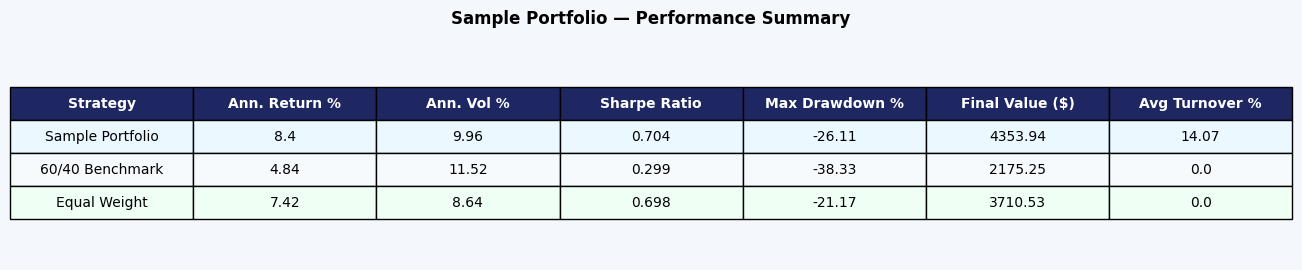

In [6]:
def compute_performance_stats(monthly_returns, strategy_label, turnover=None):
    annualized_return     = monthly_returns.mean() * 12 * 100
    annualized_volatility = monthly_returns.std()  * np.sqrt(12) * 100
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_series  = (cumulative_value - rolling_peak) / rolling_peak
    max_drawdown     = drawdown_series.min() * 100
    final_value      = initial_investment * cumulative_value.iloc[-1]
    avg_turnover     = turnover[turnover > 0].mean() * 100 if turnover is not None else 0.0
    return pd.Series({
        "Ann. Return %"   : round(annualized_return,     2),
        "Ann. Vol %"      : round(annualized_volatility, 2),
        "Sharpe Ratio"    : round(sharpe_ratio,          3),
        "Max Drawdown %"  : round(max_drawdown,          2),
        "Final Value ($)" : round(final_value,           2),
        "Avg Turnover %"  : round(avg_turnover,          2),
    }, name=strategy_label)


all_strategies = {
    "Sample Portfolio" : sample_returns,
    "60/40 Benchmark"  : benchmark_60_40,
    "Equal Weight"     : equal_weight_returns,
}

summary_table = pd.DataFrame([
    compute_performance_stats(
        monthly_returns, label,
        turnover=turnover_series if label == "Sample Portfolio" else None
    )
    for label, monthly_returns in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())
print()
print("Key question: does a thoughtfully designed static allocation")
print("beat a naive equal-weight baseline and the 60/40 benchmark?")

# ── Visual summary table ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis("off")
col_labels = ["Strategy"] + list(summary_table.columns)
row_data   = [[idx] + [str(v) for v in summary_table.loc[idx]] for idx in summary_table.index]
table = ax.table(cellText=row_data, colLabels=col_labels,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)
row_colors = ["#EBF8FF", "#F7FAFC", "#F0FFF4"]
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1E2761")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i, color in enumerate(row_colors, start=1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)
ax.set_title("Sample Portfolio — Performance Summary",
             fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

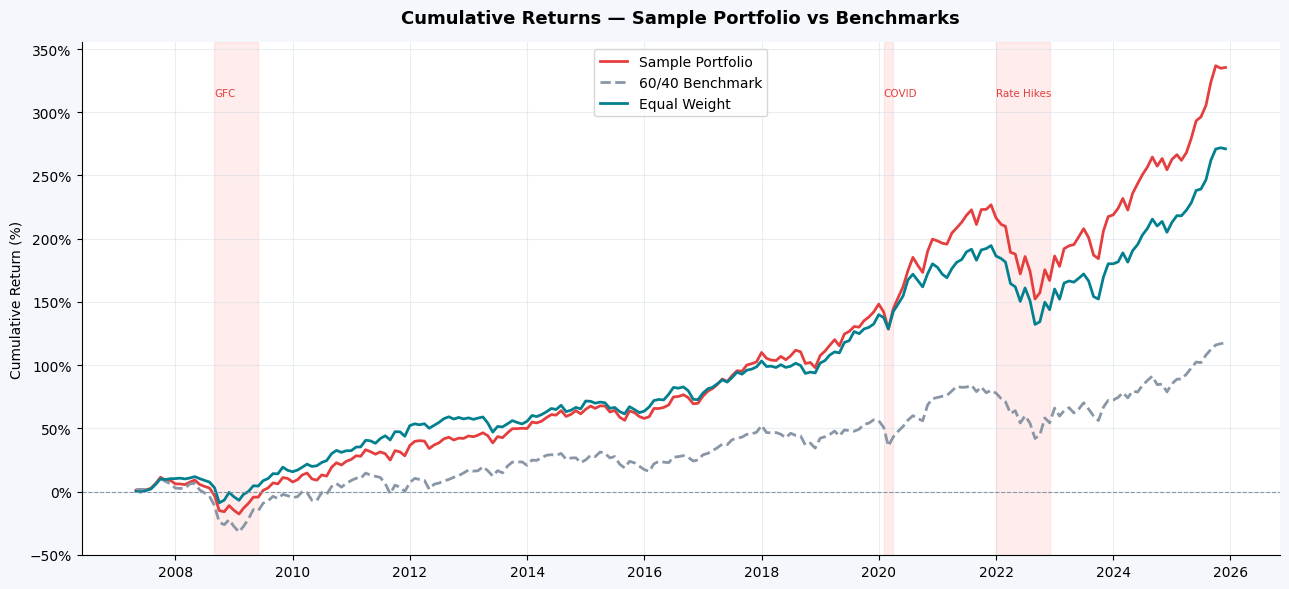

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    ls = "--" if label == "60/40 Benchmark" else "-"
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2, linestyle=ls)

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — Sample Portfolio vs Benchmarks",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

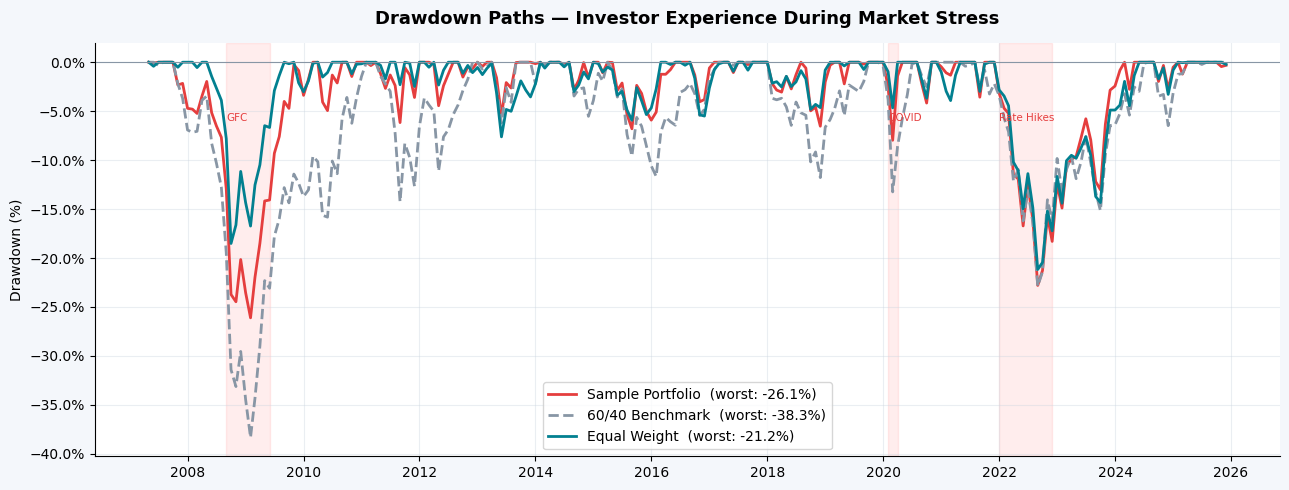

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    ls = "--" if label == "60/40 Benchmark" else "-"
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2, linestyle=ls)

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — Investor Experience During Market Stress",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

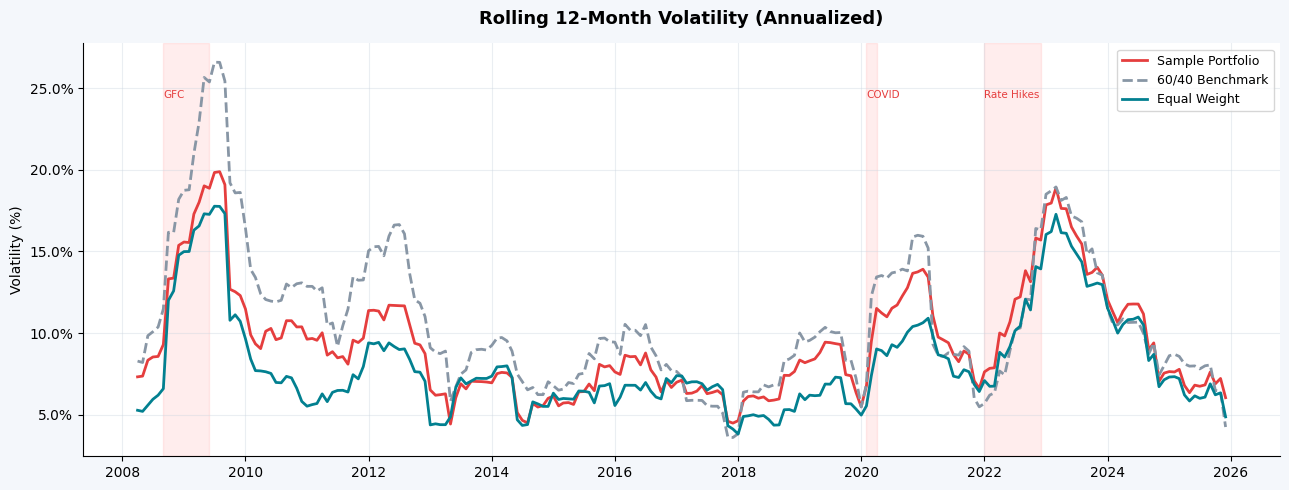

In [11]:
rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    ls = "--" if label == "60/40 Benchmark" else "-"
    rolling_vol = (
        monthly_returns.rolling(rolling_window_months).std() * np.sqrt(12) * 100
    )
    ax.plot(rolling_vol, label=label,
            color=PALETTE[label], linewidth=2, linestyle=ls)

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [12]:

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    """
    Returns number of months from drawdown trough to full recovery.
    Returns None if not yet recovered by end of data.
    """
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date  = recovered_months.index[0]
    months_elapsed = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>24}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>24}" if months is None else f"{months} months".rjust(24)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Crisis                  Sample Portfolio         60/40 Benchmark            Equal Weight
----------------------------------------------------------------------------------------
GFC                            13 months               24 months               11 months
COVID                           2 months                5 months                1 months
Rate Hikes                     18 months               23 months               21 months


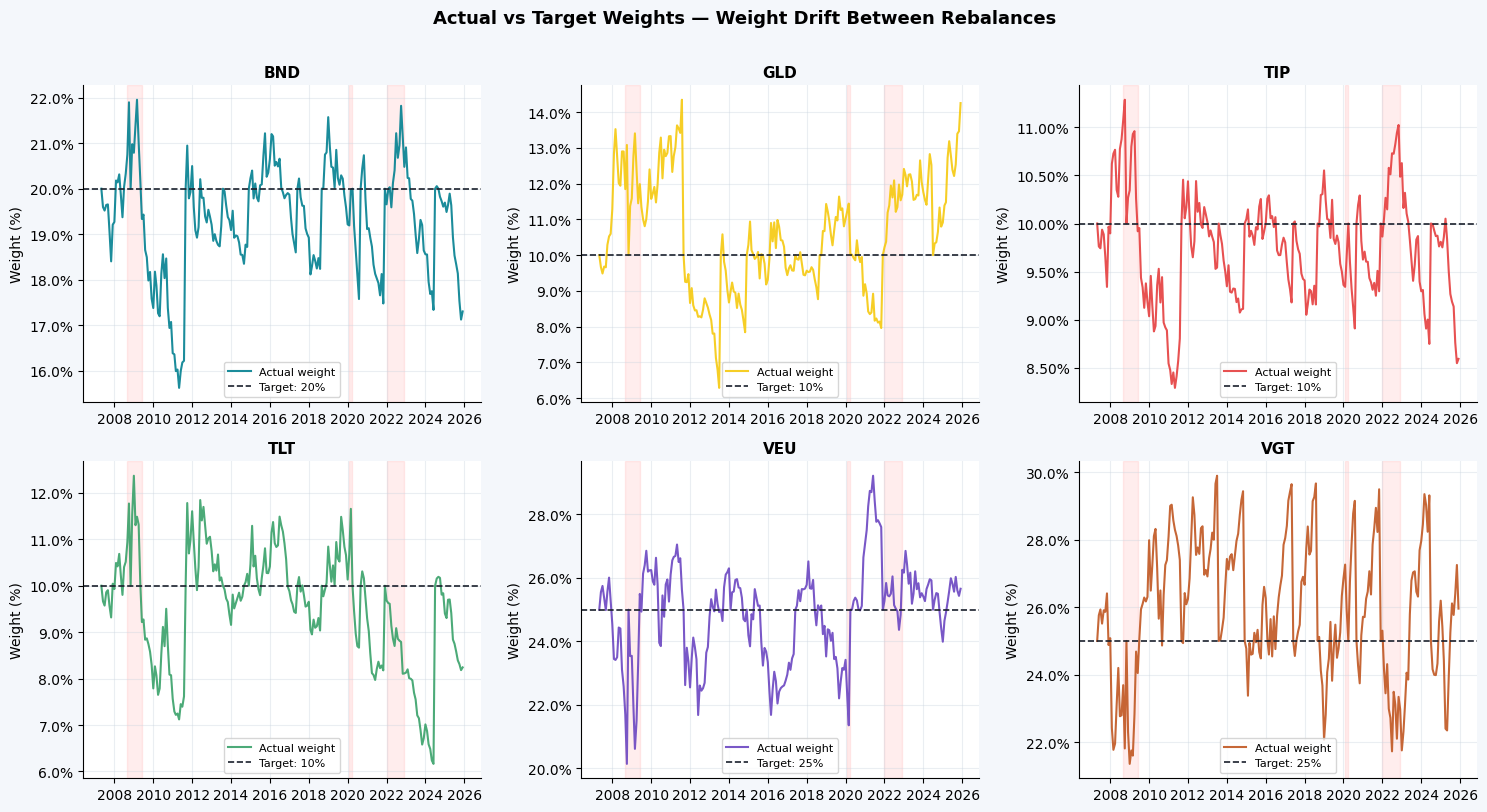

In [ ]:
# Target vs Actual Weights
# Shows how much the portfolio drifts from its targets between rebalances.
# Large drift = the rebalancing threshold is doing meaningful work.
# Small drift = the portfolio barely moves from its targets.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
target_color = "#1A202C"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for asset_index, asset_name in enumerate(assets):
    ax = axes[asset_index]
    actual_weight_pct = rolling_weights_df[asset_name] * 100
    target_weight_pct = TARGET_WEIGHTS[asset_name] * 100

    ax.plot(actual_weight_pct,
            color=asset_colors[asset_index], linewidth=1.5,
            label="Actual weight", alpha=0.9)
    ax.axhline(target_weight_pct,
               color=target_color, linewidth=1.2,
               linestyle="--", label=f"Target: {target_weight_pct:.0f}%")

    for crisis_start, crisis_end, _ in CRISES:
        ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
                   alpha=0.07, color="red")

    ax.set_title(asset_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Weight (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=8)

fig.suptitle("Actual vs Target Weights — Weight Drift Between Rebalances",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

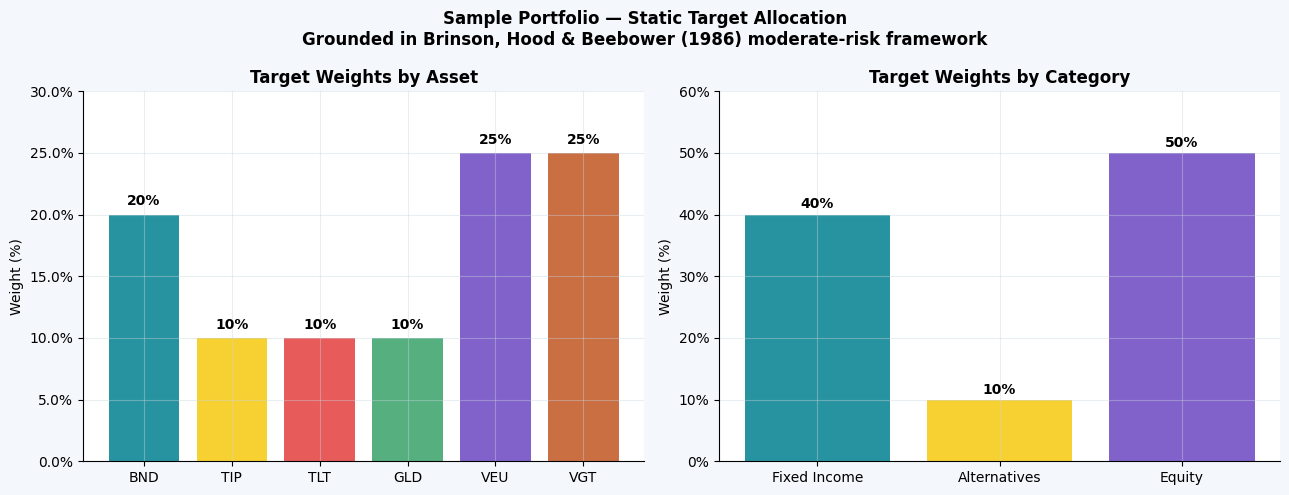

In [14]:

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

categories = {
    "Fixed Income" : ["BND", "TIP", "TLT"],
    "Alternatives" : ["GLD"],
    "Equity"       : ["VEU", "VGT"],
}
category_totals = {
    cat: sum(TARGET_WEIGHTS[a] for a in assets_in_cat)
    for cat, assets_in_cat in categories.items()
}

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

# Left: individual asset weights
asset_names   = list(TARGET_WEIGHTS.keys())
asset_weights = [w * 100 for w in TARGET_WEIGHTS.values()]
bars = ax_left.bar(asset_names, asset_weights, color=asset_colors, alpha=0.85)
for bar, weight in zip(bars, asset_weights):
    ax_left.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{weight:.0f}%",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_left.set_title("Target Weights by Asset", fontsize=12, fontweight="bold")
ax_left.set_ylabel("Weight (%)")
ax_left.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_left.set_ylim(0, max(asset_weights) * 1.2)

# Right: category totals
category_colors = ["#028090", "#F6C90E", "#6B46C1"]
cat_names   = list(category_totals.keys())
cat_weights = [w * 100 for w in category_totals.values()]
bars_cat = ax_right.bar(cat_names, cat_weights, color=category_colors, alpha=0.85)
for bar, weight in zip(bars_cat, cat_weights):
    ax_right.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.5,
                  f"{weight:.0f}%",
                  ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_right.set_title("Target Weights by Category", fontsize=12, fontweight="bold")
ax_right.set_ylabel("Weight (%)")
ax_right.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_right.set_ylim(0, max(cat_weights) * 1.2)

fig.suptitle(
    "Sample Portfolio — Static Target Allocation\n"
    "Grounded in Brinson, Hood & Beebower (1986) moderate-risk framework",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

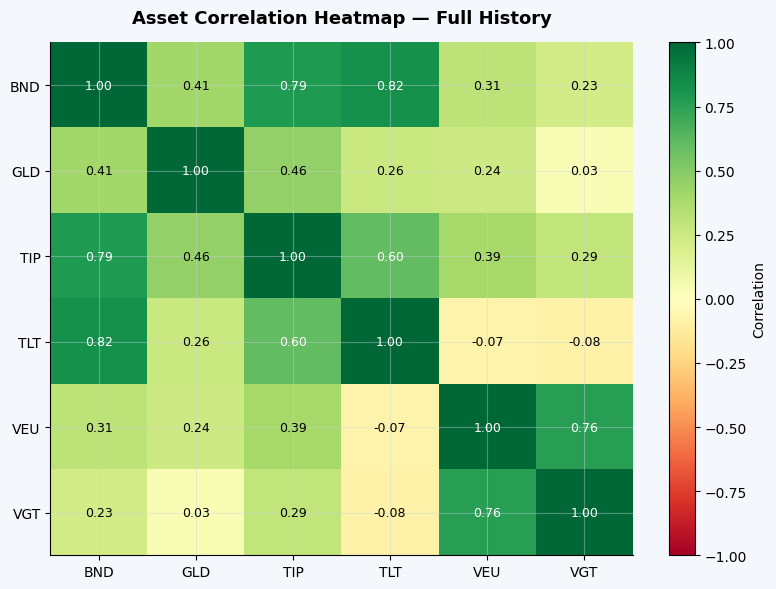

In [15]:
import matplotlib.colors as mcolors

correlation_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
colormap = plt.cm.RdYlGn
heatmap  = ax.imshow(correlation_matrix, cmap=colormap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_xticks(range(len(assets)))
ax.set_yticks(range(len(assets)))
ax.set_xticklabels(assets, fontsize=10)
ax.set_yticklabels(assets, fontsize=10)

for row_index in range(len(assets)):
    for col_index in range(len(assets)):
        correlation_value = correlation_matrix.iloc[row_index, col_index]
        text_color        = "white" if abs(correlation_value) > 0.6 else "black"
        ax.text(col_index, row_index,
                f"{correlation_value:.2f}",
                ha="center", va="center",
                fontsize=9, color=text_color)

ax.set_title("Asset Correlation Heatmap — Full History",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()